In [95]:
# [환경 설정] 한글 폰트 설정 및 필수 라이브러리 로드
# macOS, Windows, Linux, Google Colab 환경에 맞춰 한글 깨짐 없이 동작하도록 자동 감지 설정합니다.

import platform
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import pandas as pd
import numpy as np

try:
    import seaborn as sns
except ImportError:
    pass

# 운영체제(OS)별 한글 폰트 자동 설정
system_name = platform.system()
if system_name == 'Darwin':          # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
    plt.rcParams['font.sans-serif'] = ['AppleGothic', 'Apple SD Gothic Neo', 'NanumGothic', 'DejaVu Sans']
elif system_name == 'Windows':       # Windows
    plt.rcParams['font.family'] = 'Malgun Gothic'
    plt.rcParams['font.sans-serif'] = ['Malgun Gothic', 'NanumGothic', 'DejaVu Sans']
else:                               # Linux / Google Colab
    try:
        nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
        if nanum_fonts:
            plt.rcParams['font.family'] = nanum_fonts[0]
        else:
            import subprocess
            subprocess.run(['apt-get', 'install', '-y', 'fonts-nanum'], check=False, stdout=subprocess.DEVNULL)
            fm.fontManager.addfont('/usr/share/fonts/truetype/nanum/NanumGothic.ttf')
            plt.rcParams['font.family'] = 'NanumGothic'
    except Exception:
        pass
    plt.rcParams['font.sans-serif'] = ['NanumGothic', 'DejaVu Sans']

# 마이너스 기호 깨짐 방지 및 Seaborn 폰트 동기화
plt.rcParams['axes.unicode_minus'] = False
try:
    if 'sns' in locals():
        sns.set_theme(style='whitegrid', font=plt.rcParams['font.family'])
except Exception:
    pass

print(f'✅ 환경 설정 완료! 현재 적용된 폰트: {plt.rcParams["font.family"]}')

✅ 환경 설정 완료! 현재 적용된 폰트: ['NanumGothic']


## 실습 1. 문자열 날짜를 시간으로 변환
글자로 읽힌 날짜를 진짜 시간 값으로 바꾸기

목표
- 글자로 읽힌 날짜를 진짜 시간 값으로 바꾸기

단계
- 샘플을 열고 시간 열의 자료형을 먼저 확인
- 시간 변환 함수로 글자를 시간 값으로 바꾸기
- 바뀐 자료형을 다시 확인해 변환 성공을 확인

예상 결과
- 자료형이 글자에서 시간 형식으로 바뀜

In [96]:
df = pd.read_csv('20_engine01_timestamp_sample.csv')
print(df.shape)

(182, 6)


In [97]:
# to_datetime부터 적용해봅시다!
print(f'원래 timestamp 컬럼의 타입은 {df['timestamp'].dtype}입니다.')

# timestamp 컬럼을 시간타입을 바꿔서 새로 만들어 갈아끼웁시다!
df['timestamp'] = pd.to_datetime(df['timestamp'])

print(f'변환된 timestamp 컬럼의 타입은 {df['timestamp'].dtype}입니다.')

원래 timestamp 컬럼의 타입은 object입니다.
변환된 timestamp 컬럼의 타입은 datetime64[ns]입니다.


## 실습 2. 시간 조각 추출과 파생 열
변환한 시간 열에서 연·월·일·시를 꺼내고 새 열 만들기

목표
- 변환한 시간 열에서 연·월·일·시 조각을 꺼내고 파생 열 만들기

단계
- 시간 접근자로 연·월·일·시를 각각 꺼내 첫 값 확인
- 시 조각을 새 열로 추가하기
- 새 열의 앞부분을 확인해 시간대별 분석을 준비

예상 결과
- 첫 행이 2024년 3월 1일 0시, 시 열 앞 세 값은 0·1·2

In [1]:
# timestamp 컬럼이 datetime64 타입이라서 부분을 뽑내기 가능 : year, day, hour, min ...
print(df['timestamp'].dt.year.head(1))
print(df['timestamp'].dt.month.head(1))
print(df['timestamp'].dt.day.head(1))

# 다른 방식으로 첫 값 확인
print(df['timestamp'].dt.year.iloc[1])
print(df['timestamp'].dt.month.iloc[1])
print(df['timestamp'].dt.day.iloc[1])
print(df['timestamp'].dt.hour.iloc[1])

# hour 시리즈를 기존 df에 새로운 컬럼으로 추가
df['hour'] = df['timestamp'].dt.hour
print(df['hour'].head(3).tolist())

NameError: name 'df' is not defined

## 실습 3. 시간 인덱스 만들고 정렬
시간 열을 인덱스로 올리고 정렬해 분석 준비 완료

목표
- 시간 열을 인덱스로 올리고 정렬해 시간 분석을 준비

단계
- 시간 열을 인덱스로 끌어올려 결과를 다시 담기
- 인덱스 종류를 확인해 시간 인덱스인지 보기
- 정렬 뒤 첫·마지막 시각과 전체 행 수 확인

예상 결과
- 시간 인덱스로 바뀌고 3월 1일 0시~8일 23시, 182행

In [99]:
df = df.set_index('timestamp').sort_index()
print(df.index.dtype)

print(df.index[0])
print(df.index[-1])

print("전체행: ",len(df))

datetime64[ns]
2024-03-01 00:00:00
2024-03-08 23:00:00
전체행:  182


## 실습 4. 시간 인덱스로 기간 잘라보기
특정 날짜와 기간을 시간 인덱스로 골라내기

목표
- 시간 인덱스로 특정 날짜와 기간을 골라내기

단계
- 하루 날짜를 넣어 그 날 데이터만 선택
- 시작과 끝 날짜를 콜론으로 이어 기간 선택
- 각 결과의 행 수로 기간 크기 확인

예상 결과
- 3월 2일 하루 20행, 3월 5일~7일 사흘 70행(끝 포함)

In [100]:
day = df.loc['2024-03-02']
print(len(day))

range = df.loc['2024-03-05' : '2024-03-07']
print(len(range))

20
70


## 실습 5. 시간 단위 평균·최댓값 집계
리샘플링으로 단위를 바꿔 대표값 계산

목표
- 시간 단위를 바꿔 묶고 평균·최댓값 대표값을 계산

단계
- 6시간 단위로 묶어 평균을 구하고 앞부분 확인
- 같은 단위로 최댓값을 구해 평균과 비교
- 최댓값이 평균보다 큼을 수치로 확인

예상 결과
- 6시간 첫 구간 평균 약 641.06, 최댓값 641.18

In [105]:
# 시계열로 timestamp를 정렬된 인스덱로 만들어서
# 다운샘플링하기
# 1. 어떤 단위로 다시 묶을 것인가? : 시간단위 -> 일, 6시간, ...
# 2. 새로 묶어서 통계내는 대상 컬럼은? : temp_out을 써봅시다

# timestamp가 인덱스로 잡힌 것 확인
print(df['temp_out'].head(3))

# 6시간 단위로 다운샘플링해서 temp_out 컬럼의 평균들을 구하기
print(df['temp_out'].resample('6h').mean().head(3))

print(df['temp_out'].resample('6h').max().head(3))
print(df['temp_out'].resample('6h').min().head(3))
print(df['temp_out'].resample('6h').median().head(3))


timestamp
2024-03-01 00:00:00    641.17
2024-03-01 01:00:00    640.66
2024-03-01 02:00:00    641.08
Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    641.058333
2024-03-01 06:00:00    641.005000
2024-03-01 12:00:00    640.953333
Freq: 6h, Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    641.18
2024-03-01 06:00:00    641.27
2024-03-01 12:00:00    641.23
Freq: 6h, Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    640.66
2024-03-01 06:00:00    640.84
2024-03-01 12:00:00    640.71
Freq: 6h, Name: temp_out, dtype: float64
timestamp
2024-03-01 00:00:00    641.130
2024-03-01 06:00:00    640.955
2024-03-01 12:00:00    640.935
Freq: 6h, Name: temp_out, dtype: float64


## 실습 6. 리샘플링 단위와 데이터 성김
묶는 단위를 바꿔 다운샘플링 효과를 체험

목표
- 묶는 단위를 바꿔 데이터가 성겨지는 다운샘플링을 체험

단계
- 한 시간·6시간·12시간 단위로 각각 묶어 평균 구하기
- 각 결과의 행 수를 세어 비교
- 단위가 클수록 행 수가 줄어 흐름이 매끄러워짐을 확인

예상 결과
- 한 시간 192행, 6시간 32행, 12시간 16행으로 줄어듦

In [112]:
print(len(df['temp_out'].resample('1h').mean()))
print(len(df['temp_out'].resample('6h').mean()))
print(len(df['temp_out'].resample('12h').mean()))

# 조금 더 머리를 써봅시다!
for time in ['1h', '6h', '12h']:
  print(len(df['temp_out'].resample(time).mean()))

192
32
16
192
32
16


## 실습 7. 일별 집계로 추세 확인
일별 평균으로 잡음을 걸러 추세를 원본과 겹쳐 확인

목표
- 일별 평균으로 잡음을 걸러 낸 추세를 원본과 겹쳐 확인

단계
- 하루 단위 평균을 구하고 앞부분 확인
- 원본을 옅게, 일별 평균을 진하게 겹쳐 그리기
- 첫날과 마지막날 평균을 비교해 추세 방향 판정

예상 결과
- 일별 평균 641.07에서 642.35로 상승, 매끄러운 추세선

timestamp
2024-03-01    641.067273
2024-03-02    641.340000
2024-03-03    641.557917
Freq: D, Name: temp_out, dtype: float64


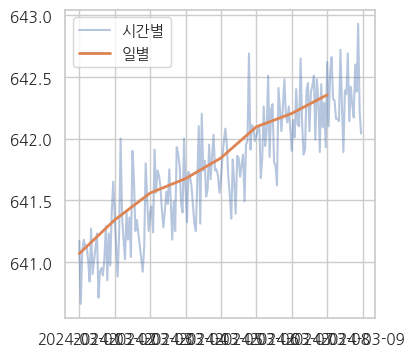

첫날 평균 641.07에서 마지막날 642.35로 변했습니다.


In [126]:
daily = df['temp_out'].resample('1D').mean()
print(daily.head(3))

plt.figure(figsize=(4, 4))
plt.plot(df.index, df['temp_out'], alpha=0.4, label='시간별')
plt.plot(daily.index, daily.values, linewidth=2, label='일별')
plt.legend()
plt.show()

print(f'첫날 평균 {daily.iloc[0].round(2)}에서 마지막날 {daily.iloc[-1].round(2)}로 변했습니다.')

## 실습 8. 업샘플링 결측과 보간
촘촘하게 만들 때 생기는 결측과 원본 결측을 보간으로 채우기

목표
- 업샘플링으로 생기는 결측과 원본의 기존 결측을 보간으로 채우기

단계
- 30분 단위로 촘촘하게 만들어 생긴 결측 세기
- 보간으로 빈 값을 채우고 결측이 0이 됨을 확인
- 원본에 원래 있던 결측도 보간으로 메우기

예상 결과
- 업샘플링 결측 201이 보간 후 0, 진동 원본 결측 3도 0

In [134]:
up = df['flow'].resample('30min').mean()
print(up.head())
print("업샘플링 결측: ", up.isna().sum().sum())
print("보간 후 결측:", up.interpolate().isna().sum().sum())

# interpolate가 메꿔주기엔 탁원하구나!
# 그럼 이미 3개가 비어보이는 vibration에도 적용해보자
print("진동 결측: ", df['vibration'].isna().sum().sum())
print("진동 보간 후 결측:", df['vibration'].interpolate().isna().sum().sum())


timestamp
2024-03-01 00:00:00    8.344
2024-03-01 00:30:00      NaN
2024-03-01 01:00:00    8.385
2024-03-01 01:30:00      NaN
2024-03-01 02:00:00    8.436
Freq: 30min, Name: flow, dtype: float64
업샘플링 결측:  201
보간 후 결측: 0
진동 결측:  3
진동 보간 후 결측: 0
